# Collaboration Networks

Co-authorship relationships are a [common](https://networks.skewed.de/?tags=Collaboration) dataset type to use in network analysis. 
Often these are presented as _already being networks_, so that each edge is exactly a coathoring (via one or more papers) between two individuals. 

However, using this kind of network as a stand-in for the underlying _social network_ among authors can be problematic, since co-occurrence counts inherently imply a dense, clique-based observation model, and when activations can arise from, for instance, a _spreading process_ --- think, asking your colleagues to join you and having them agree---and will therefore cause _clique bias_. 
See [Sexton (2025)](https://dissertation.rtbs.dev/content/part2/2-04-rand-sf.html#sec-clique-bias). 

In this example, we demonstrate three network reconstruction approaches using synthesized collaboration data under a spreading-process assumption. 


In [1]:
import numpy as np
import networkx as nx
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import affinis.associations as aff 
from affinis.filter import threshold_connected
from affinis.plots import hinton

rng = np.random.default_rng(42)
sns.set_theme(style='white')
imgpath=Path('../../docs/case-studies/img/')
plt.rc('figure', figsize=(4.0, 3.0))

## Problem Setting

Let's create a synthetic network of colleagues. 
Each "edge" represents a working relationship, where they have a "close enough" to reliably expect asking the other to join them on papers, regularly. 

We might expect 1-3 close working relationships for someone in an office, with the occaisional possibility for cliques to be created. 

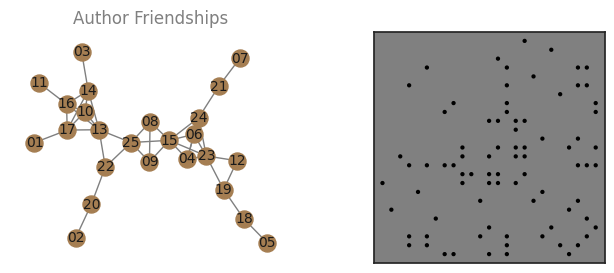

In [2]:
n_authors=25
author_idx = pd.CategoricalIndex((f'author_{i:>02}' for i in range(1,n_authors+1)))

# friends with some cliques
friendships = nx.line_graph(nx.random_labeled_tree(len(author_idx)+1, seed=7))

G = nx.relabel.relabel_nodes(
    nx.convert_node_labels_to_integers(friendships),
    dict(zip(range(n_authors),author_idx.categories.tolist()))
) 

A = nx.adjacency_matrix(G).todense()
L = nx.laplacian_matrix(G).todense()

def draw_G(G, ax=None):
    if ax is None: 
        ax=plt.gca()
    pos=nx.layout.kamada_kawai_layout(G)
    nx.draw(G, pos=pos, node_size=150,
            node_color='xkcd:puce', edge_color='grey', ax=ax)
    nx.draw_networkx_labels(G, pos=pos, font_color='k', font_size=10,
                            labels={n:n.split('_')[-1] for n in G}, ax=ax)
    ax.set_title('Author Friendships', color='grey')
    return pos

f, ax = plt.subplots(ncols=2,figsize=(8,3))
f.patch.set_alpha(0.)
pos = draw_G(G, ax=ax[0])

hinton(-A, marker='.',ax=ax[1])
plt.savefig(imgpath/'collab-net.webp')

![collaboration ground-truth](img/collab-net.webp)

If we let an initial "first" author ask a friend, then let either of them ask a friend, and so on for some number of "asks" (say, until time runs out to add new authors), then we have modeled co-authorship as a kind of _spreading process_.


Let's simulate this process of authors joining each paper. 

- Let's say 1 paper each week, on average, for 1 year. 
- For each:
    * We select a random individual to intiate it. 
    * We spread the paper's concept to colleagues.
    * A geometrically distributed number of requests to join will be successful,
    * Each request comes from an existing author, able to ask any of their connected colleagues to join

For our data, represent each paper as a row, and the authors on a given paper each week as "active" (True) columns in that row. 

In [3]:
def sim_papers(n_weeks, L, jumps_param=0.1, rng=np.random.default_rng(2)): 
    Arw = ((L/np.diag(L)).pipe(lambda df: np.diag(np.diag(df))-df)*0.5)
    def sim_week(): 
        n_jumps = rng.geometric(jumps_param)
        first = rng.multinomial(1,starting:=np.ones(n_authors)/n_authors) 
        # second = (rng.random()>0.5)*rng.multinomial(1,starting)  # maybe
        infected = first #| second
        for jump in range(n_jumps):
            # print((Arw@infected>1).sum(), infected)
            infected = infected | rng.binomial(1, Arw@(infected/infected.sum()))
        return infected


    yield from (sim_week() for i in range(n_weeks))

L_df = pd.DataFrame(L, columns=author_idx, index=author_idx)

X = np.vstack([paper for paper in sim_papers(52,L_df, 0.05)])
Xdf = pd.DataFrame(X, columns=author_idx)

## Author relationship recovery

Now let's attempt to recover as many true relationships as we can for this network, using only the paper co-authorship data we generated. 
To perform a thresholding of edge weights relative to the method we pick, we can use the [`threshold_connected`][affinis.filter.threshold_connected] rule. 

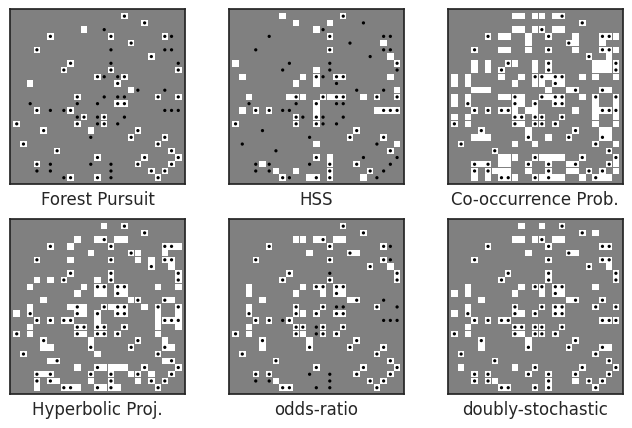

In [8]:
psct ='min-connect'
# psct=0

baselines = {
    # 'Chow Liu Tree': aff.chow_liu(X, pseudocts=psct),
    'Forest Pursuit': aff.forest_pursuit(X,pseudocts=psct),  
    'HSS': aff.high_salience_skeleton(X, pseudocts=psct),
    'Co-occurrence Prob.': aff.coocur_prob(X, pseudocts=psct),
    'Hyperbolic Proj.': aff.hyperbolic_project(X),
    'odds-ratio': aff.odds_ratio(X, pseudocts=psct),
    'doubly-stochastic':aff.doubly_stochastic_filter(X, reg=0.1,pseudocts=psct),
    
}
f,axs = plt.subplots(nrows=2, ncols=3, figsize=(8,5))

for n, (lab, Aest) in enumerate(baselines.items()): 
    ax = axs.flatten()[n]
    # ax.imshow(Aest)
    hinton(threshold_connected(Aest), ax=ax)
    hinton(-A, marker='.', ax=ax)
    ax.set_xlabel(lab)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

plt.savefig(imgpath/'collab-recover.webp')

![thresholded collaborations](img/collab-recover.webp)


## Cross-Threshold Evaluation

Since we have the true network (for this synthetic case), we can also compare the overall performance of each algorithm accross all possible threshold values. 

The [`contingency` library](https://github.com/usnistgov/Contingency) makes these kinds of binary classification metrics simple to calculate!

In [12]:
from contingency import Contingent
from contingency.plots import PR_contour
from scipy.spatial.distance import squareform

y_true = squareform(A).astype(bool)
y_fp = squareform(baselines['Forest Pursuit'])
y_ds = squareform(baselines['doubly-stochastic'],checks=False)

m_fp = Contingent.from_scalar(y_true, y_fp)
m_ds = Contingent.from_scalar(y_true, y_ds)

Let's look at how the _Matthew's Correlation Coefficient_ (MCC) changes for Forest Pursuit v.s. Hyperbolic Projection: 

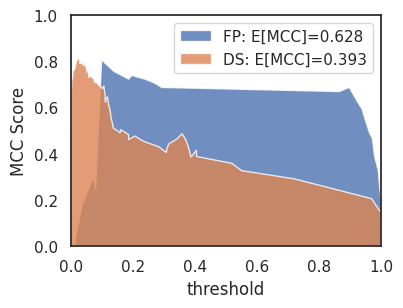

In [13]:
ax=plt.subplot()
ax.fill(
    m_fp.weights, m_fp.mcc, 
    alpha=0.8,label=f'FP: E[MCC]={m_fp.expected('mcc'):.3f}'
)
ax.fill(
    m_ds.weights, m_ds.mcc, 
    alpha=0.8,label=f'DS: E[MCC]={m_ds.expected('mcc'):.3f}'
)
ax.set(xlim=(0,1),ylim=(0,1),xlabel='threshold',ylabel='MCC Score')
plt.legend()
plt.savefig(imgpath/'collab-mcc.webp')

![MCC score thresholds](img/collab-mcc.webp)

Meanwhile, precision scores will drop off sharply for sparse, stable predictions like (default) Forest Pursuit, in order to let Recall sufficiently increase. 

This illustrates why one might want to use the `interaction` probability mode (FPi), instead: 


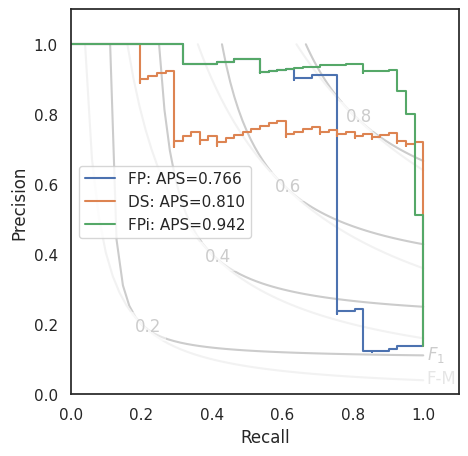

In [14]:
m_fpi = Contingent.from_scalar(y_true, squareform(aff.forest_pursuit(X, mode='interaction')))

f = plt.figure(figsize=(5,5))
ax=plt.gca()
PR_contour(ax=ax)
plt.step(
    m_fp.recall, m_fp.precision, 
    where='post',label=f'FP: APS={m_fp.expected('aps'):.3f}'
)
plt.step(
    m_hyp.recall, m_hyp.precision, 
    where='post', label=f'DS: APS={m_hyp.expected('aps'):.3f}'
)
plt.step(
    m_fpi.recall, m_fpi.precision, 
    where='post', label=f'FPi: APS={m_fpi.expected('aps'):.3f}'
)
plt.legend()
plt.savefig(imgpath/'collab-PR.webp')

![pr-curve](img/collab-PR.webp)